## HTA analysis


In [1]:
import zipfile
import os


# 1. using path for the tracer logs saved
ZIP_SOURCE_PATH = "/content/drive/MyDrive/MSML_610/profiler_trace_files"

# 2. Where to extract them for HTA (Keep this consistent)
ANALYSIS_OUTPUT_PATH = "./hta_analysis"

In [2]:
# Verify source exists
if not os.path.exists(ZIP_SOURCE_PATH):
    print(f"Error: The source path '{ZIP_SOURCE_PATH}' does not exist.")
else:
    # Find zip files in that specific folder
    zip_files = [f for f in os.listdir(ZIP_SOURCE_PATH) if f.endswith('.zip')]

    if not zip_files:
        print(f" No .zip files found inside {ZIP_SOURCE_PATH}")
    else:
        print(f" Found {len(zip_files)} zip files.")

        for zf in zip_files:
            # Full path to the zip file
            full_zip_path = os.path.join(ZIP_SOURCE_PATH, zf)

            # Create a specific folder for this run in the analysis directory
            # e.g., stage2_trace.zip -> ./hta_analysis/stage2_trace/
            folder_name = zf.replace(".zip", "")
            extract_path = os.path.join(ANALYSIS_OUTPUT_PATH, folder_name)

            print(f"   extracting: {zf} \n  -> to: {extract_path}")

            try:
                with zipfile.ZipFile(full_zip_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_path)
            except zipfile.BadZipFile:
                print(f"Error: {zf} is corrupt.")

        print("\n--- FINAL FOLDER STRUCTURE FOR HTA ---")
        for root, dirs, files in os.walk(ANALYSIS_OUTPUT_PATH):
            level = root.replace(ANALYSIS_OUTPUT_PATH, '').count(os.sep)
            indent = ' ' * 4 * (level)
            print(f"{indent}{os.path.basename(root)}/")
            for f in files:
                if f.endswith('.json') or f.endswith('.gz'):
                    print(f"{indent}    {f}")

 Found 3 zip files.
   extracting: deepspeed_stage2_trace.zip 
  -> to: ./hta_analysis/deepspeed_stage2_trace
   extracting: deepspeed_stage3_trace.zip 
  -> to: ./hta_analysis/deepspeed_stage3_trace
   extracting: deepspeed_zeropp_trace.zip 
  -> to: ./hta_analysis/deepspeed_zeropp_trace

--- FINAL FOLDER STRUCTURE FOR HTA ---
hta_analysis/
    deepspeed_zeropp_trace/
        deepspeed_zeropp_trace/
            e9b764cef546_1635.1764734346073085690.pt.trace.json
            e9b764cef546_1636.1764734345842034861.pt.trace.json
        __MACOSX/
            deepspeed_zeropp_trace/
                ._e9b764cef546_1635.1764734346073085690.pt.trace.json
                ._e9b764cef546_1636.1764734345842034861.pt.trace.json
    deepspeed_stage2_trace/
        deepspeed_stage2_trace/
            e9b764cef546_491.1764732007918481049.pt.trace.json
            merged_multi_gpu_trace.json
            e9b764cef546_490.1764732007835768228.pt.trace.json
        __MACOSX/
            deepspeed_stage2_t

In [3]:
!pip3 install hta
!pip install HolisticTraceAnalysis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.2/371.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.3 MB/s eta 0:00:00


In [ ]:
from hta.trace_analysis import TraceAnalysis
import os
import glob
import json
import gc
import shutil

# --- CONFIGURATION ---
# Define source folders (Where your unzipped files are)
source_traces = {
    "Stage 2": "./hta_analysis/deepspeed_stage2_trace/deepspeed_stage2_trace",
    "Stage 3": "./hta_analysis/deepspeed_stage3_trace/deepspeed_stage3_trace",
    "ZeRO++": "./hta_analysis/deepspeed_zeropp_trace/deepspeed_zeropp_trace"
}

# Define where to save the "Fast" sliced versions
FAST_DIR_BASE = "./hta_analysis/fast_slices"
TARGET_STEP = 3  # We will extract only Step 3 for analysis

# --- HELPER: SLICER FUNCTION ---
def create_fast_slice(src_dir, stage_name):
    """Reads a huge trace, extracts ONE step, saves to a new folder."""
    output_dir = os.path.join(FAST_DIR_BASE, stage_name.replace(" ", "_"))
    os.makedirs(output_dir, exist_ok=True)

    print(f"  Slicing '{stage_name}' to ensure fast analysis...")

    # Get json files
    files = [f for f in glob.glob(os.path.join(src_dir, "*.json"))
             if "merged" not in f and not os.path.basename(f).startswith("._")]

    if not files:
        print(f"   No files found in {src_dir}")
        return None

    # 1. Find time window from first file
    start_ts, end_ts = 0, 0
    try:
        with open(files[0], 'r') as f:
            data = json.load(f)
            events = data.get("traceEvents", [])
            for e in events:
                # Look for the specific step marker
                if f"Step {TARGET_STEP}" in e.get("name", ""):
                    start_ts = e["ts"]
                    end_ts = start_ts + e["dur"]
                    break
    except:
        pass

    # Fallback if specific step not found: Take first 2 seconds
    if start_ts == 0:
        print("   Target step not found, slicing first 2 seconds instead.")
        with open(files[0], 'r') as f: # Re-read to be safe
            data = json.load(f)
            start_ts = data.get("traceEvents", [])[0]["ts"]
            end_ts = start_ts + 2_000_000 # 2s window

    # 2. Slice all files
    for t_file in files:
        out_path = os.path.join(output_dir, os.path.basename(t_file))
        # Skip if already sliced to save time
        if os.path.exists(out_path): continue

        try:
            with open(t_file, 'r') as f:
                data = json.load(f)

            # Keep events inside the window
            sliced = [e for e in data["traceEvents"] if "ts" in e and start_ts <= e["ts"] <= end_ts]
            data["traceEvents"] = sliced

            with open(out_path, 'w') as f:
                json.dump(data, f)

            # Cleanup RAM
            del data, sliced
            gc.collect()
        except Exception as e:
            print(f"      Error slicing {os.path.basename(t_file)}: {e}")

    return output_dir

# --- MAIN ANALYSIS LOOP ---
print("---  PREPARING DATA FOR HTA (Smart Slicing Mode) ---")

for name, path in source_traces.items():
    if not os.path.exists(path):
        print(f"Warning: Source folder for {name} not found at {path}")
        continue

    # 1. Slice the trace first (Solves the RAM/Timeout issues)
    analysis_target_path = create_fast_slice(path, name)

    if not analysis_target_path:
        continue

    # Check if slice succeeded
    sliced_files = glob.glob(os.path.join(analysis_target_path, "*.json"))
    if not sliced_files:
        print(f" Slicing failed for {name}, skipping.")
        continue

    print(f"\n---  ANALYZING: {name} (Fast Mode) ---")

    try:
        # 2. Initialize HTA on the SLICED folder
        analyzer = TraceAnalysis(trace_dir=analysis_target_path)

        # 3. Generate Plots
        print(f"   1. Generating Temporal Breakdown...")
        fig1 = analyzer.get_temporal_breakdown(visualize=True)
        fig1.show() # Explicitly show plot

        print(f"   2. Generating Overlap Analysis...")
        fig2 = analyzer.get_comm_comp_overlap(visualize=True)
        fig2.show() # Explicitly show plot

    except Exception as e:
        print(f"  HTA Analysis Failed: {e}")

print("\n--- All Analysis Complete ---")

---  PREPARING DATA FOR HTA (Smart Slicing Mode) ---
  Slicing 'Stage 2' to ensure fast analysis...

---  ANALYZING: Stage 2 (Fast Mode) ---


   1. Generating Temporal Breakdown...


  HTA Analysis Failed: 'DataFrame' object has no attribute 'show'
  Slicing 'Stage 3' to ensure fast analysis...

---  ANALYZING: Stage 3 (Fast Mode) ---


   1. Generating Temporal Breakdown...


  HTA Analysis Failed: 'DataFrame' object has no attribute 'show'
  Slicing 'ZeRO++' to ensure fast analysis...

---  ANALYZING: ZeRO++ (Fast Mode) ---


   1. Generating Temporal Breakdown...


  HTA Analysis Failed: 'DataFrame' object has no attribute 'show'

--- All Analysis Complete ---


--- STARTING ANALYSIS ---
  Slicing 'Stage 2'...

==================== Stage 2 ====================



📊 Temporal Breakdown: Stage 2


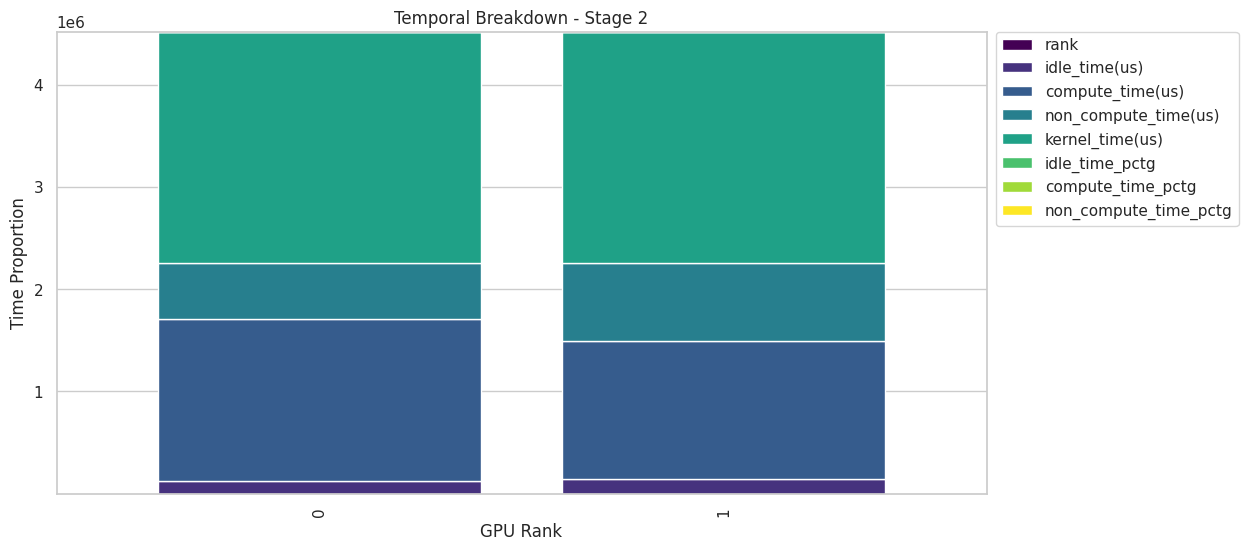


📊 Comm/Comp Overlap: Stage 2


/usr/local/lib/python3.12/dist-packages/hta/analyzers/communication_analysis.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comm_kernels.melt(var_name="status", value_name="time").replace(
/usr/local/lib/python3.12/dist-packages/hta/analyzers/communication_analysis.py:59: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comp_kernels.melt(var_name="status", value_name="time").replace(
/usr/local/lib/python3.12/dist-packages/hta/analyzers/communication_analysis.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated

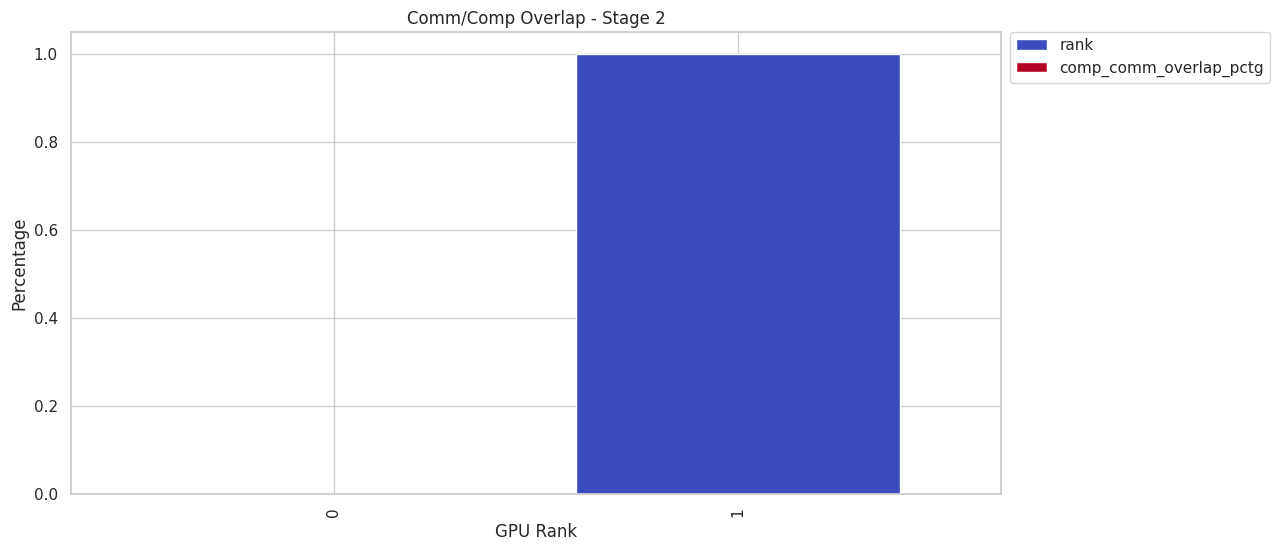

  Slicing 'Stage 3'...

==================== Stage 3 ====================



📊 Temporal Breakdown: Stage 3


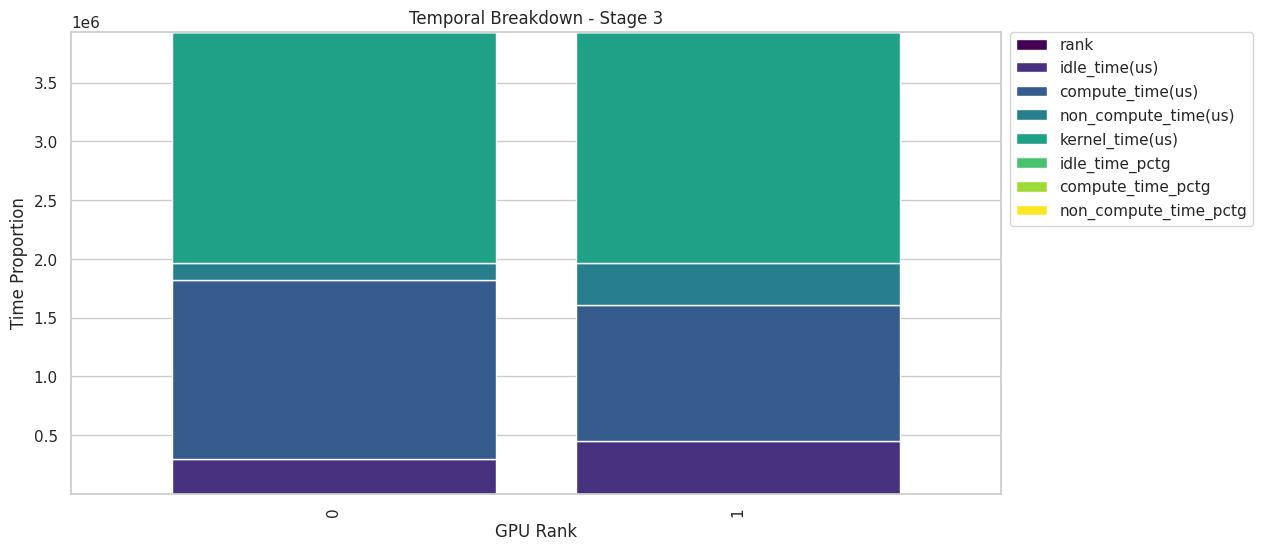


📊 Comm/Comp Overlap: Stage 3


/usr/local/lib/python3.12/dist-packages/hta/analyzers/communication_analysis.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comm_kernels.melt(var_name="status", value_name="time").replace(
/usr/local/lib/python3.12/dist-packages/hta/analyzers/communication_analysis.py:59: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comp_kernels.melt(var_name="status", value_name="time").replace(
/usr/local/lib/python3.12/dist-packages/hta/analyzers/communication_analysis.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated

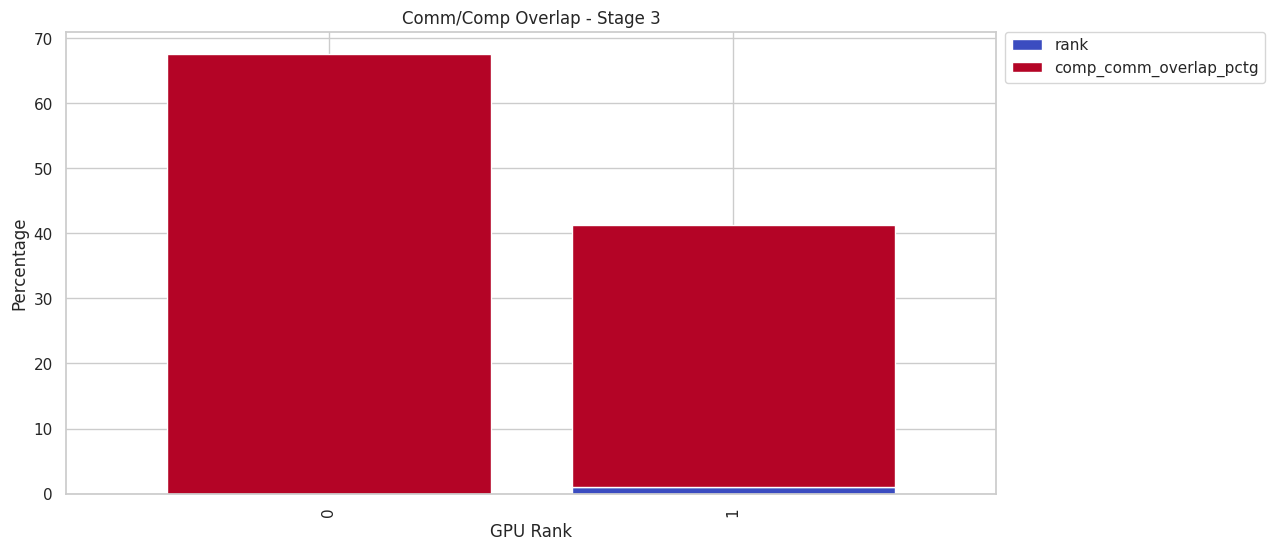

  Slicing 'ZeRO++'...

==================== ZeRO++ ====================



📊 Temporal Breakdown: ZeRO++


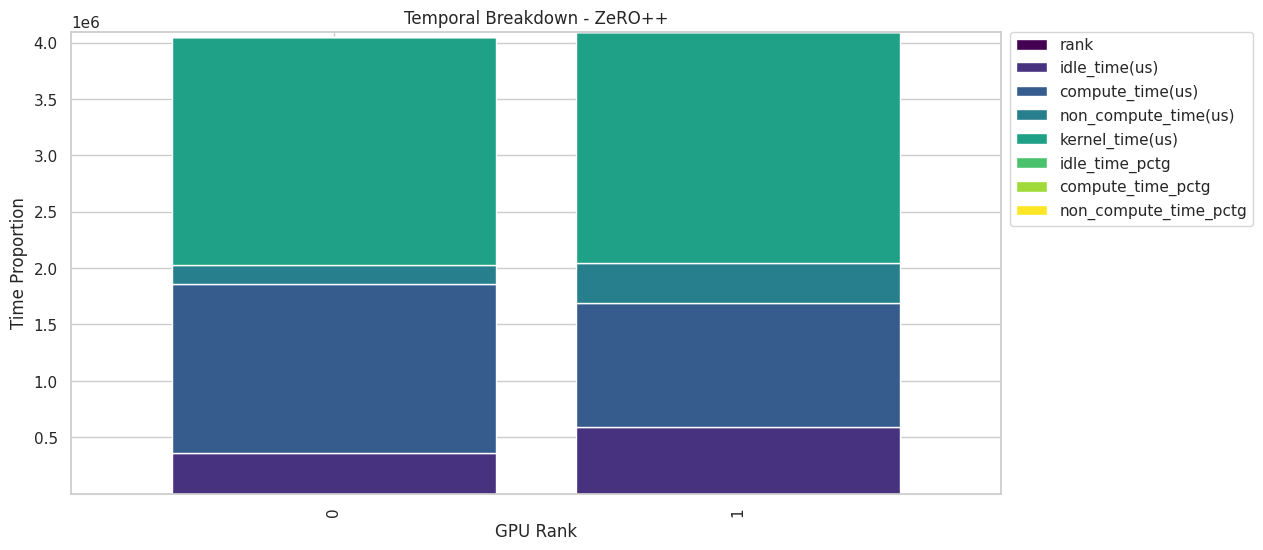


📊 Comm/Comp Overlap: ZeRO++


/usr/local/lib/python3.12/dist-packages/hta/analyzers/communication_analysis.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comm_kernels.melt(var_name="status", value_name="time").replace(
/usr/local/lib/python3.12/dist-packages/hta/analyzers/communication_analysis.py:59: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comp_kernels.melt(var_name="status", value_name="time").replace(
/usr/local/lib/python3.12/dist-packages/hta/analyzers/communication_analysis.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated

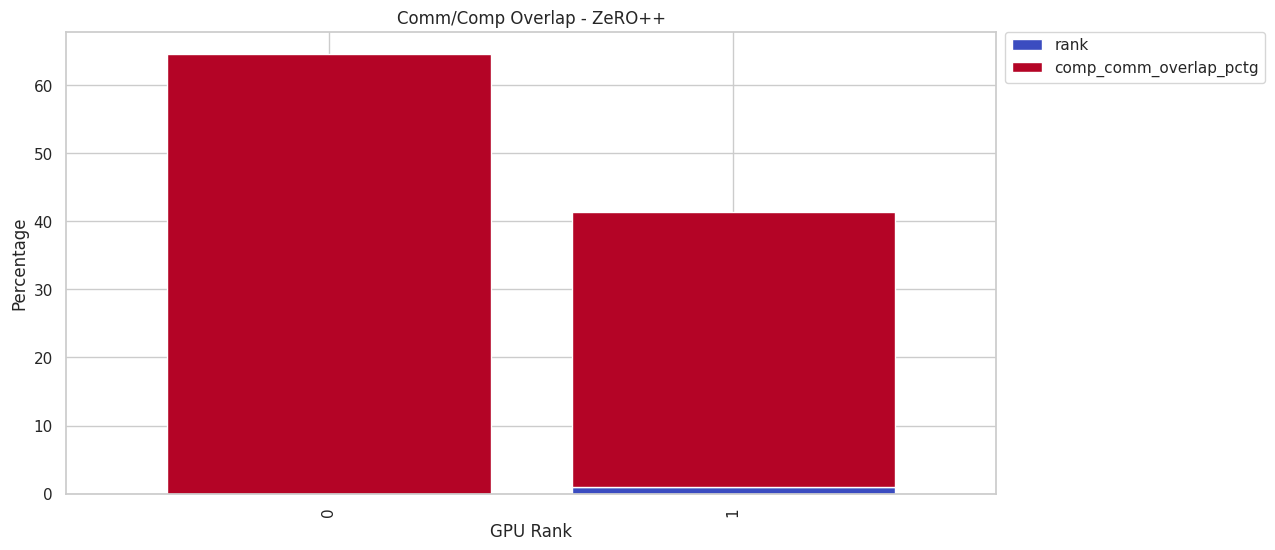

In [5]:
from hta.trace_analysis import TraceAnalysis
import os
import glob
import json
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure plots display inline in Jupyter
%matplotlib inline

# --- CONFIGURATION ---
source_traces = {
    "Stage 2": "./hta_analysis/deepspeed_stage2_trace/deepspeed_stage2_trace",
    "Stage 3": "./hta_analysis/deepspeed_stage3_trace/deepspeed_stage3_trace",
    "ZeRO++": "./hta_analysis/deepspeed_zeropp_trace/deepspeed_zeropp_trace"
}

FAST_DIR_BASE = "./hta_analysis/fast_slices"
TARGET_STEP = 3

# Set plot style for better visibility
sns.set_theme(style="whitegrid")

# --- HELPER: SLICER FUNCTION ---
def create_fast_slice(src_dir, stage_name):
    """Reads a huge trace, extracts ONE step, saves to a new folder."""
    output_dir = os.path.join(FAST_DIR_BASE, stage_name.replace(" ", "_"))
    os.makedirs(output_dir, exist_ok=True)

    print(f"  Slicing '{stage_name}'...")

    files = [f for f in glob.glob(os.path.join(src_dir, "*.json"))
             if "merged" not in f and not os.path.basename(f).startswith("._")]

    if not files:
        print(f"   No files found in {src_dir}")
        return None

    # Find time window
    start_ts, end_ts = 0, 0
    try:
        with open(files[0], 'r') as f:
            data = json.load(f)
            events = data.get("traceEvents", [])
            for e in events:
                if f"Step {TARGET_STEP}" in e.get("name", ""):
                    start_ts = e["ts"]
                    end_ts = start_ts + e["dur"]
                    break
    except:
        pass

    # Fallback if step not found
    if start_ts == 0:
        with open(files[0], 'r') as f:
            data = json.load(f)
            start_ts = data.get("traceEvents", [])[0]["ts"]
            end_ts = start_ts + 2_000_000

    # Slice files
    for t_file in files:
        out_path = os.path.join(output_dir, os.path.basename(t_file))
        if os.path.exists(out_path): continue

        try:
            with open(t_file, 'r') as f:
                data = json.load(f)
            sliced = [e for e in data["traceEvents"] if "ts" in e and start_ts <= e["ts"] <= end_ts]
            data["traceEvents"] = sliced
            with open(out_path, 'w') as f:
                json.dump(data, f)
            del data, sliced
            gc.collect()
        except Exception:
            pass

    return output_dir

# --- HELPER: INLINE PLOTTING FUNCTION ---
def show_inline_plots(analyzer, stage_name):
    """Extracts data and uses Matplotlib to show plots directly in the notebook output."""

    # 1. Temporal Breakdown
    try:
        print(f"\n📊 Temporal Breakdown: {stage_name}")
        # Get raw data (Pandas DataFrame)
        temp_df = analyzer.get_temporal_breakdown(visualize=False)

        # Create Plot
        plt.figure(figsize=(12, 6))
        # Plot directly from the DataFrame
        temp_df.plot(kind='bar', stacked=True, width=0.8, colormap='viridis', figsize=(12, 6), ax=plt.gca())

        plt.title(f"Temporal Breakdown - {stage_name}")
        plt.xlabel("GPU Rank")
        plt.ylabel("Time Proportion")
        plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
        plt.show() # <--- Renders plot here in the notebook

    except Exception as e:
        print(f"      Could not generate Temporal Breakdown: {e}")

    # 2. Communication vs Computation Overlap
    try:
        print(f"\n📊 Comm/Comp Overlap: {stage_name}")
        # Get raw data (Pandas DataFrame)
        overlap_df = analyzer.get_comm_comp_overlap(visualize=False)

        # Create Plot
        plt.figure(figsize=(12, 6))
        overlap_df.plot(kind='bar', stacked=True, width=0.8, colormap='coolwarm', figsize=(12, 6), ax=plt.gca())

        plt.title(f"Comm/Comp Overlap - {stage_name}")
        plt.xlabel("GPU Rank")
        plt.ylabel("Percentage")
        plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
        plt.show() # <--- Renders plot here in the notebook

    except Exception as e:
        print(f"      Could not generate Overlap Analysis: {e}")

# --- MAIN LOOP ---
print("--- STARTING ANALYSIS ---")

for name, path in source_traces.items():
    if not os.path.exists(path):
        continue

    # Slice first
    analysis_target_path = create_fast_slice(path, name)
    if not analysis_target_path: continue

    # Analyze
    print(f"\n{'='*20} {name} {'='*20}")
    try:
        analyzer = TraceAnalysis(trace_dir=analysis_target_path)
        show_inline_plots(analyzer, name)
    except Exception as e:
        print(f"Analysis failed for {name}: {e}")